# Exploratory Data Analysis (EDA)
## Predicting Customer Lifetime Value to Optimize Value-Based Bidding and Paid Advertising Budget Allocation

**Student:** Christian Alan Vibar\
**Course:** MAB2134 Analytics Algorithms 1 (Predictive Analytics 1)  
**Term:** 3rd / SY 2025–2026  
**Instructor:** Francis Adrian Viernes, CFA, MBA, MSF, CCREP, PMDSA

---

### Purpose of this notebook
This notebook covers the Data Understanding phase of CRISP-DM for the project. It documents the target distribution, feature distributions, data quality audit, bivariate relationships, and segment analysis. Findings from this EDA directly inform the preprocessing plan and modeling hypotheses for the project.

---

### Data Overview

**Source:** Internal company data warehouse (production gold layer). PII scrubbed prior to use.  
**Cohort:** Customers acquired between the years 2020 and 2026. All records have been ensured to have a complete 12-month revenue observation window as of the pull date.  
**Pull date:** 05/05/2026\
**Data Dictionary:** [Access in Github](https://github.com/christianvibar/mab2134_algo1/blob/5bcf33e33eee997443789d7bad652647520dc872/data_dictionary.md)\
**File used:** `mab2134_data_raw.csv`

The data was extracted using the following query:

```sql
SELECT 
    CONCAT(unified_client_id, '_', lifecycle) AS client_id,
    hubspot_client_id,
    lifecycle,
    channel,
    broader_source,
    broad_source,
    service_offering,
    campaign_group,
    campaign,
    ad_group,
    ad,
    ad_network,
    creative_group,
    creative_variation,
    keyword_text,
    keyword_match_type,
    placement,
    facebook_ad_set_audience,
    client_country,
    client_location_state,
    client_local_timezone,
    cb_city,
    email_type,
    email_industry_type,
    cb_jobtitle_type,
    cb_employees_range,
    cb_annual_revenue_ranges,
    cb_industry,
    cb_sector,
    cb_industry_group,
    cb_sub_industry,
    attributed_at,
    DATE(attributed_at) AS attributed_date,
    signup_at,
    signup_date,
    customer_date,
    first_billing_week,
    last_billing_week,
    revenue_first_1_month,
    revenue_first_2_months,
    revenue_first_3_months,
    revenue_first_6_months,
    total_revenue,
    starting_mrr,
    latest_mrr,
    profit,
    active_weeks,
    revenue_first_12_months
FROM `fivetran-magic-warehouse-fmdl.dbt_production.dim_clients_multi_lcs`
WHERE fivetran_deleted = FALSE
    AND invalid_contact_flag = FALSE
    AND is_merged = FALSE
    AND revenue_first_12_months IS NOT NULL
    AND active_weeks >= 51
```

> **Note on reproducibility:** The source data is proprietary company data and was retrieved via the organization's data warehouse. The SQL query above is purely for documentation. All analysis in this notebook is reproducible from the CSV file given the query above.

---
## 0. Preliminaries

In [13]:
# BASIC PACKAGES
%matplotlib auto
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# REPRODUCIBILITY
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# DISPLAY OPTIONS
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_rows', 100)

# AESTHETICS
sns.set_style('whitegrid')
plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = 'Blues_d'

print('Packages loaded successfully.')

Using matplotlib backend: module://matplotlib_inline.backend_inline
Packages loaded successfully.


---
## 1. Data Loading & Initial Inspection

In [2]:
# LOAD DATA
FILE_PATH = '../data/mab2134_data_raw.csv'

df_orig = pd.read_csv(FILE_PATH)

# Always work on a copy; keep original untouched for reference
df = df_orig.copy()

print(f'File loaded: {FILE_PATH}')
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')

File loaded: ../data/mab2134_data_raw.csv
Shape: 1,273 rows × 48 columns


In [3]:
# DTYPES AND NULL SUMMARY
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1273 entries, 0 to 1272
Data columns (total 48 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   client_id                 1273 non-null   object 
 1   hubspot_client_id         1273 non-null   float64
 2   lifecycle                 1273 non-null   int64  
 3   channel                   1139 non-null   object 
 4   broader_source            1139 non-null   object 
 5   broad_source              1139 non-null   object 
 6   service_offering          620 non-null    object 
 7   campaign_group            1141 non-null   object 
 8   campaign                  1141 non-null   object 
 9   ad_group                  1141 non-null   object 
 10  ad                        1141 non-null   object 
 11  ad_network                1141 non-null   object 
 12  creative_group            1141 non-null   object 
 13  creative_variation        1141 non-null   object 
 14  keyword_

In [4]:
# FIRST ROWS
df.head()

,client_id,hubspot_client_id,lifecycle,channel,broader_source,broad_source,service_offering,campaign_group,campaign,ad_group,ad,ad_network,creative_group,creative_variation,keyword_text,keyword_match_type,placement,facebook_ad_set_audience,client_country,client_location_state,client_local_timezone,cb_city,email_type,email_industry_type,cb_jobtitle_type,cb_employees_range,cb_annual_revenue_ranges,cb_industry,cb_sector,cb_industry_group,cb_sub_industry,attributed_at,attributed_date,signup_at,signup_date,customer_date,first_billing_week,last_billing_week,revenue_first_1_month,revenue_first_2_months,revenue_first_3_months,revenue_first_6_months,total_revenue,starting_mrr,latest_mrr,profit,active_weeks,revenue_first_12_months
0,680247841beb878e1a8ff164f7296de7_1,96349503.0000,1,import,offline,offline,NaN,no_campaign_group,-,-,-,-,non_facebook_ad,non_facebook_ad,NaN,NaN,NaN,not_facebook,united states,unknown,America/New_York,norwalk,paid_email,NaN,senior leadership,Nov-50,$1M-$10M,Renewable Electricity,Utilities,Independent Power and Renewable Electricity Pr...,Renewable Energy,2023-09-19T19:52:22.747000,19/09/2023,2023-09-21T06:19:23.375000,21/09/2023,11/11/2023,11/11/2023,31/05/2025,4641.4286,7092.8571,9458.5714,17209.2857,38415.0000,649.5000,649.5000,12805.0000,79,31605.0000
1,79448c4c120cc3750709546d6ae90974_2,17680601.0000,2,duckduckgo,organic_inbound,organic_search,executive_assistant,no_campaign_group,-,-,-,-,non_facebook_ad,non_facebook_ad,appointment setting services,BROAD,NaN,not_facebook,united states,tennessee,America/New_York,chattanooga,paid_email,NaN,senior leadership,01-Oct,$0-$1M,Diversified Consumer Services,Consumer Discretionary,Consumer Services,Specialized Consumer Services,2023-10-19T07:33:47.875000,19/10/2023,2023-10-19T07:32:32.602000,19/10/2023,28/10/2023,28/10/2023,26/07/2025,814.2857,2147.1429,3501.4286,7358.5714,29535.0000,1299.0000,1299.0000,13660.0000,78,20764.2857
2,c07f9ec7fc78d410859d0b28fd84e676_1,98397401.0000,1,youtube,organic_inbound,social_media,executive_assistant,no_campaign_group,-,-,-,-,non_facebook_ad,non_facebook_ad,NaN,NaN,NaN,not_facebook,united states,colorado,America/Denver,austin,paid_email,NaN,senior leadership,01-Oct,$0-$1M,Professional Services,Industrials,Commercial & Professional Services,Human Resource & Employment Services,2023-10-05T15:58:17.255000,05/10/2023,2023-10-05T15:58:02.697000,05/10/2023,28/10/2023,28/10/2023,31/01/2026,2588.5714,5005.7143,7662.8571,14897.1429,69840.0000,2598.0000,2598.0000,32032.0000,118,30668.5714
3,569fb2f5603e35479366d72bbe5db4c3_1,101630651.0000,1,twitter,paid_inbound,paid_inbound,executive_assistant,no_campaign_group,Executive Assistants 0919,Executive Assistants - Business Leadership - 1017,-,twitter,non_facebook_ad,non_facebook_ad,NaN,NaN,NaN,not_facebook,united states,unknown,America/New_York,addison,paid_email,NaN,senior leadership,Nov-50,$1M-$10M,Professional Services,Industrials,Commercial & Professional Services,Professional Services,2023-10-29T06:49:20.403000,29/10/2023,2023-10-29T06:49:02.896000,29/10/2023,25/11/2023,25/11/2023,15/11/2025,1668.5714,2554.2857,3382.8571,6011.4286,21240.0000,866.0000,866.0000,10620.0000,104,11240.0000
4,c60bc3c3e7f5e366c660d5266553f2e3_1,25132237210.0000,1,integration,offline,offline,NaN,no_campaign_group,-,-,-,-,non_facebook_ad,non_facebook_ad,NaN,NaN,NaN,not_facebook,united states,california,America/Los_Angeles,los altos,paid_email,other_brokerage_firms,non-senior leadership,NaN,NaN,Real Estate,Financials,Real Estate,Real Estate,2024-05-28T17:17:45.052000,28/05/2024,2024-05-29T00:00:00,29/05/2024,08/06/2024,08/06/2024,04/10/2025,5914.2857,9900.0000,12205.7143,16075.7143,47475.0000,3897.0000,3897.0000,24627.2500,70,35790.0000


In [7]:
# DESCRIPTIVE STATISTICS
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
client_id,1273,1272,3216f95d01345717af5094d8dc916f26_1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hubspot_client_id,1273.0000,NaN,NaN,NaN,13872852984.9914,32158434977.4519,119.0000,31511601.0000,60091551.0000,108572601.0000,216705000000.0000
lifecycle,1273.0000,NaN,NaN,NaN,1.1469,0.4020,1.0000,1.0000,1.0000,1.0000,5.0000
channel,1139,42,adwords,343,NaN,NaN,NaN,NaN,NaN,NaN,NaN
broader_source,1139,6,paid_inbound,535,NaN,NaN,NaN,NaN,NaN,NaN,NaN
broad_source,1139,13,paid_inbound,535,NaN,NaN,NaN,NaN,NaN,NaN,NaN
service_offering,620,9,virtual_assistant,356,NaN,NaN,NaN,NaN,NaN,NaN,NaN
campaign_group,1141,5,no_campaign_group,600,NaN,NaN,NaN,NaN,NaN,NaN,NaN
campaign,1141,102,-,563,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ad_group,1141,184,-,563,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 1.1 Column Name Cleanup

In [8]:
# Standardize column names: strip whitespace, lowercase
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print('Cleaned column names:')
print(df.columns.tolist())

Cleaned column names:
['client_id', 'hubspot_client_id', 'lifecycle', 'channel', 'broader_source', 'broad_source', 'service_offering', 'campaign_group', 'campaign', 'ad_group', 'ad', 'ad_network', 'creative_group', 'creative_variation', 'keyword_text', 'keyword_match_type', 'placement', 'facebook_ad_set_audience', 'client_country', 'client_location_state', 'client_local_timezone', 'cb_city', 'email_type', 'email_industry_type', 'cb_jobtitle_type', 'cb_employees_range', 'cb_annual_revenue_ranges', 'cb_industry', 'cb_sector', 'cb_industry_group', 'cb_sub_industry', 'attributed_at', 'attributed_date', 'signup_at', 'signup_date', 'customer_date', 'first_billing_week', 'last_billing_week', 'revenue_first_1_month', 'revenue_first_2_months', 'revenue_first_3_months', 'revenue_first_6_months', 'total_revenue', 'starting_mrr', 'latest_mrr', 'profit', 'active_weeks', 'revenue_first_12_months']


### 1.2 Column Value Cleanup

In [9]:
# Standardize column values: strip whitespace, lowercase
str_cols = df.select_dtypes(include='object').columns.tolist()

for col in str_cols:
    df[col] = df[col].str.strip().str.lower().str.replace(' ', '_', regex=False)

# Print head to check again
df.head()

,client_id,hubspot_client_id,lifecycle,channel,broader_source,broad_source,service_offering,campaign_group,campaign,ad_group,ad,ad_network,creative_group,creative_variation,keyword_text,keyword_match_type,placement,facebook_ad_set_audience,client_country,client_location_state,client_local_timezone,cb_city,email_type,email_industry_type,cb_jobtitle_type,cb_employees_range,cb_annual_revenue_ranges,cb_industry,cb_sector,cb_industry_group,cb_sub_industry,attributed_at,attributed_date,signup_at,signup_date,customer_date,first_billing_week,last_billing_week,revenue_first_1_month,revenue_first_2_months,revenue_first_3_months,revenue_first_6_months,total_revenue,starting_mrr,latest_mrr,profit,active_weeks,revenue_first_12_months
0,680247841beb878e1a8ff164f7296de7_1,96349503.0000,1,import,offline,offline,NaN,no_campaign_group,-,-,-,-,non_facebook_ad,non_facebook_ad,NaN,NaN,NaN,not_facebook,united_states,unknown,america/new_york,norwalk,paid_email,NaN,senior_leadership,nov-50,$1m-$10m,renewable_electricity,utilities,independent_power_and_renewable_electricity_pr...,renewable_energy,2023-09-19t19:52:22.747000,19/09/2023,2023-09-21t06:19:23.375000,21/09/2023,11/11/2023,11/11/2023,31/05/2025,4641.4286,7092.8571,9458.5714,17209.2857,38415.0000,649.5000,649.5000,12805.0000,79,31605.0000
1,79448c4c120cc3750709546d6ae90974_2,17680601.0000,2,duckduckgo,organic_inbound,organic_search,executive_assistant,no_campaign_group,-,-,-,-,non_facebook_ad,non_facebook_ad,appointment_setting_services,broad,NaN,not_facebook,united_states,tennessee,america/new_york,chattanooga,paid_email,NaN,senior_leadership,01-oct,$0-$1m,diversified_consumer_services,consumer_discretionary,consumer_services,specialized_consumer_services,2023-10-19t07:33:47.875000,19/10/2023,2023-10-19t07:32:32.602000,19/10/2023,28/10/2023,28/10/2023,26/07/2025,814.2857,2147.1429,3501.4286,7358.5714,29535.0000,1299.0000,1299.0000,13660.0000,78,20764.2857
2,c07f9ec7fc78d410859d0b28fd84e676_1,98397401.0000,1,youtube,organic_inbound,social_media,executive_assistant,no_campaign_group,-,-,-,-,non_facebook_ad,non_facebook_ad,NaN,NaN,NaN,not_facebook,united_states,colorado,america/denver,austin,paid_email,NaN,senior_leadership,01-oct,$0-$1m,professional_services,industrials,commercial_&_professional_services,human_resource_&_employment_services,2023-10-05t15:58:17.255000,05/10/2023,2023-10-05t15:58:02.697000,05/10/2023,28/10/2023,28/10/2023,31/01/2026,2588.5714,5005.7143,7662.8571,14897.1429,69840.0000,2598.0000,2598.0000,32032.0000,118,30668.5714
3,569fb2f5603e35479366d72bbe5db4c3_1,101630651.0000,1,twitter,paid_inbound,paid_inbound,executive_assistant,no_campaign_group,executive_assistants_0919,executive_assistants_-_business_leadership_-_1017,-,twitter,non_facebook_ad,non_facebook_ad,NaN,NaN,NaN,not_facebook,united_states,unknown,america/new_york,addison,paid_email,NaN,senior_leadership,nov-50,$1m-$10m,professional_services,industrials,commercial_&_professional_services,professional_services,2023-10-29t06:49:20.403000,29/10/2023,2023-10-29t06:49:02.896000,29/10/2023,25/11/2023,25/11/2023,15/11/2025,1668.5714,2554.2857,3382.8571,6011.4286,21240.0000,866.0000,866.0000,10620.0000,104,11240.0000
4,c60bc3c3e7f5e366c660d5266553f2e3_1,25132237210.0000,1,integration,offline,offline,NaN,no_campaign_group,-,-,-,-,non_facebook_ad,non_facebook_ad,NaN,NaN,NaN,not_facebook,united_states,california,america/los_angeles,los_altos,paid_email,other_brokerage_firms,non-senior_leadership,NaN,NaN,real_estate,financials,real_estate,real_estate,2024-05-28t17:17:45.052000,28/05/2024,2024-05-29t00:00:00,29/05/2024,08/06/2024,08/06/2024,04/10/2025,5914.2857,9900.0000,12205.7143,16075.7143,47475.0000,3897.0000,3897.0000,24627.2500,70,35790.0000


### 1.3 Summary Snapshot

| Dimension | Value |
|---|---|
| Rows | *1273* |
| Columns | *48* |
| Target | `revenue_first_12_months` |

> **Observations:** Initial inspection shows that all rows have the target variable `revenue_first_12_months`. The minimum active_weeks is 51 (active weeks start at 0), ensuring that all clients in this analysis have been customers for at least 1 year. There are missing values in several independent variables that will be investigated in the Data Quality Audit section, but most notably the variables `service_offering`, `placement`, `keyword_text`, and `keyword_match_type` appears to be severely lacking.

---
## 2. Target Variable Analysis

Understanding the distribution of `revenue_first_12_months` before anything else. This is what the model will predict.

In [10]:
TARGET = 'revenue_first_12_months'

# Basic stats
print('=== Target Variable Stats ===')
print(df[TARGET].describe())
print(f'\nZero values: {(df[TARGET] == 0).sum():,}')
print(f'Negative values: {(df[TARGET] < 0).sum():,}')
print(f'Null values: {df[TARGET].isnull().sum():,}')

=== Target Variable Stats ===
count     1273.0000
mean     24123.4587
std      25748.4175
min        126.2857
25%      11000.0000
50%      18885.5479
75%      30243.7560
max     465466.1429
Name: revenue_first_12_months, dtype: float64

Zero values:    0
Negative values: 0
Null values:     0


Skewness (raw): 6.907
Skewness (log1p): -0.169


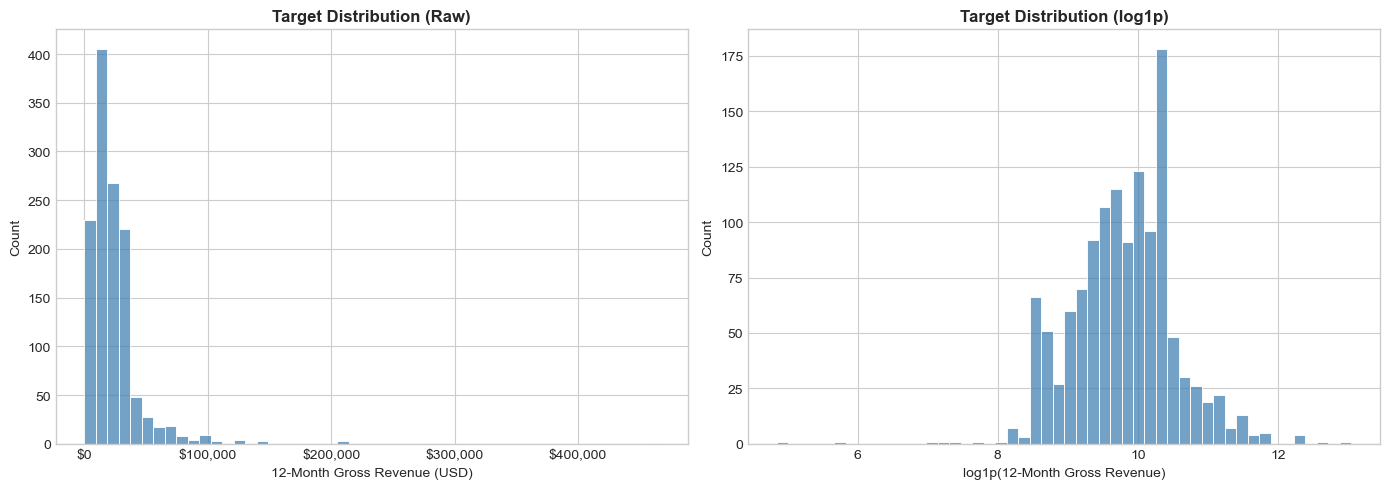

In [14]:
# DISTRIBUTION PLOT — raw and log-transformed side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw
sns.histplot(df[TARGET].dropna(), bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('Target Distribution (Raw)', fontweight='bold')
axes[0].set_xlabel('12-Month Gross Revenue (USD)')
axes[0].set_ylabel('Count')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Log-transformed (only positive values)
log_target = np.log1p(df[TARGET].dropna())
sns.histplot(log_target, bins=50, ax=axes[1], color='steelblue')
axes[1].set_title('Target Distribution (log1p)', fontweight='bold')
axes[1].set_xlabel('log1p(12-Month Gross Revenue)')
axes[1].set_ylabel('Count')

plt.tight_layout()

# Skewness check
print(f'Skewness (raw): {df[TARGET].skew():.3f}')
print(f'Skewness (log1p): {log_target.skew():.3f}')

In [15]:
# PERCENTILE TABLE
percentiles = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
pct_table = df[TARGET].quantile(percentiles).reset_index()
pct_table.columns = ['Percentile', 'Revenue (USD)']
pct_table['Percentile'] = pct_table['Percentile'].apply(lambda x: f'{x:.0%}')
print(pct_table.to_string(index=False))

Percentile  Revenue (USD)
        1%      3933.2571
        5%      5384.5714
       10%      6317.7143
       25%     11000.0000
       50%     18885.5479
       75%     30243.7560
       90%     40191.0343
       95%     60547.9973
       99%    121582.4726


### 2.1 Target Variable Observations

There are no null rows nor negative values in the target variable, ensuring that the data is valid for analysis.

When it comes to the raw distribution of the target variable, it is clear that the data is right-skewed. This is supported by the distribution plot, the mean (`$24,123`) exceeding the median (`$18,886`) by `$5,237`, and a skewness value of 6.907. This indicates it is very far from 0 (perfect symmetry). Further, the 99th percentile (`$121,583`) is 6.4x the median, confirming that a small number of high-value accounts are pulling the distribution rightward. This becomes important especially when training regression models, which assume that residuals are roughly symmetric. In its current state, the model may be dominated by these outlier accounts, which could lead to poor performance.

However, transforming the data into a log scale eliminates the skew, bringing it to -0.169 (almost negligible). Practically speaking, we will most likely have to predict using `log1p(revenue)`. This means that all evaluation of the metrics will be measured in log units and not dollars. This is important to keep note of in the modelling phase of the project. The outputs then have to be converted back to dollars before presenting to stakeholders and/or deployment.

Finally, a key note in this target variable is that this model only shows all clients who have survived at least 51 weeks or 1 year. It doesn't capture all clients who churned in weeks 1 - 50. This is okay for our use case, as we are only interested to see which customer segments tend to be more valuable so that they can be used in value based bidding in ad platforms.

---
## 3. Data Quality Audit

Three checks: missingness, duplicates, and leakage audit.

### 3.1 Missingness

In [16]:
# Missing value summary, sorted descending
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

if missing_df.empty:
    print('No missing values found.')
else:
    print(missing_df)

                          Missing Count  Missing %
placement                          1272    99.9200
email_industry_type                1154    90.6500
keyword_match_type                  947    74.3900
keyword_text                        925    72.6600
service_offering                    653    51.3000
cb_annual_revenue_ranges            347    27.2600
cb_employees_range                  335    26.3200
cb_industry                         231    18.1500
cb_sub_industry                     230    18.0700
cb_sector                           230    18.0700
cb_industry_group                   229    17.9900
cb_city                             226    17.7500
broader_source                      134    10.5300
channel                             134    10.5300
broad_source                        134    10.5300
campaign_group                      132    10.3700
ad_network                          132    10.3700
facebook_ad_set_audience            132    10.3700
creative_group                 

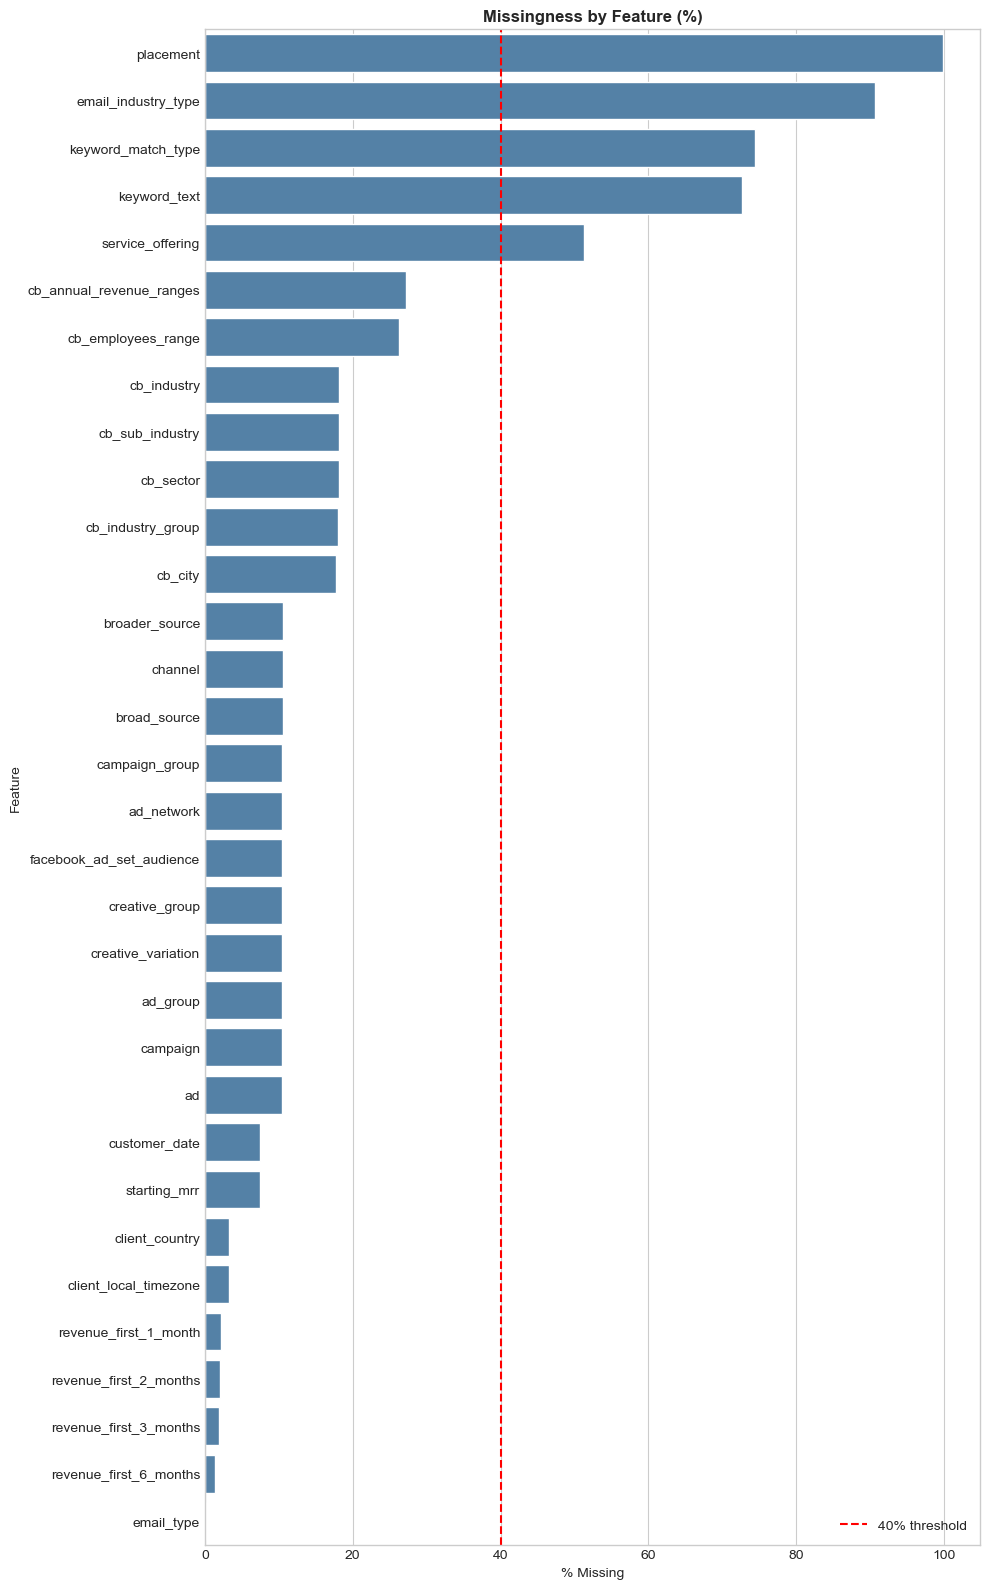

In [28]:
# Visualize missingness
if not missing_df.empty:
    fig, ax = plt.subplots(figsize=(10, max(4, len(missing_df) * 0.5)))
    sns.barplot(x='Missing %', y=missing_df.index, data=missing_df, color='steelblue', ax=ax)
    ax.set_title('Missingness by Feature (%)', fontweight='bold')
    ax.set_xlabel('% Missing')
    ax.set_ylabel('Feature')
    ax.axvline(40, color='red', linestyle='--', label='40% threshold')
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

### 3.2 Duplicates

In [19]:
# Full-row duplicates
dup_count = df.duplicated().sum()
print(f'Full-row duplicates: {dup_count:,}')

Full-row duplicates: 0


### 3.3 Leakage Audit

Every feature must be observable **at acquisition time** — before any retention, upsell, or account management action is taken. Features that reveal post-acquisition behavior are leaky.

| Feature | Observable at Acquisition? | Disposition |
|---|---|---|
| `client_id` | . | ID. Drop before modeling |
| `hubspot_client_id` | . | ID. Drop before modeling |
| `lifecycle` | Yes | Candidate feature. Numeric codes (1–5) representing customer type; cast to string before modeling to prevent ordinal misinterpretation |
| `channel` | Yes | Candidate feature. Attribution captured at acquisition |
| `broader_source` | Yes | Candidate feature. Check overlap with `broad_source` before including both |
| `broad_source` | Yes | Candidate feature. Check overlap with `broader_source` before including both |
| `service_offering` | Yes | Candidate feature. 51% missing; nulls likely reflect unattributed traffic; treat as separate category ("unattributed") rather than dropping |
| `campaign_group` | Yes | Candidate feature. Attribution captured at acquisition |
| `campaign` | Yes | Candidate feature. Attribution captured at acquisition |
| `ad_group` | Yes | Candidate feature. Attribution captured at acquisition |
| `ad` | Yes | Candidate feature. High cardinality; likely too granular to use |
| `ad_network` | Yes | Candidate feature. Attribution captured at acquisition |
| `creative_group` | Yes | Candidate feature. High cardinality; likely too granular to use |
| `creative_variation` | Yes | Candidate feature. High cardinality; likely too granular to use |
| `keyword_text` | Yes | Drop. 72% missing; too granular |
| `keyword_match_type` | Yes | Drop. 74% missing; redundant with `channel` |
| `placement` | Yes | Drop. 99% missing |
| `facebook_ad_set_audience` | Yes | Candidate feature. Only populated for Facebook traffic; treat nulls as separate category or drop |
| `client_country` | Yes | Candidate feature. Known at signup |
| `client_location_state` | Yes | Candidate feature. Known at signup |
| `client_local_timezone` | Yes | Low signal. Likely redundant with geo fields; EDA to decide |
| `cb_city` | Yes | Clearbit enrichment at lead stage. High cardinality; likely drop |
| `email_type` | Yes | Candidate feature. Enrichment at lead stage |
| `email_industry_type` | Yes | Drop. 90% missing |
| `cb_jobtitle_type` | Yes | Candidate feature. Clearbit enrichment at lead stage |
| `cb_employees_range` | Yes | Candidate feature. Clearbit enrichment at lead stage; 26% missing; treat nulls as separate category |
| `cb_annual_revenue_ranges` | Yes | Candidate feature. Clearbit enrichment at lead stage; 27% missing; treat nulls as separate category |
| `cb_industry` | Yes | Candidate feature. Clearbit; 18% missing; treat nulls as separate category |
| `cb_sector` | Yes | Candidate feature. Clearbit; likely redundant with `cb_industry` |
| `cb_industry_group` | Yes | Candidate feature. Clearbit; likely redundant with `cb_industry` |
| `cb_sub_industry` | Yes | Candidate feature. Clearbit; high cardinality |
| `starting_mrr` | Yes | Candidate feature. Reflects plan/deal configuration at first billing; 155 unique values suggest mix of clean plan tiers and deal-level variance; keep as numeric; missingness (7.4%) to be addressed in preprocessing |
| `attributed_at` / `attributed_date` | . | Timestamp. Do not use raw; may extract acquisition year/month as cohort control variable |
| `signup_at` / `signup_date` | . | Timestamp. Same as above |
| `customer_date` | . | Timestamp. Drop; post-acquisition event |
| `first_billing_week` | . | Timestamp. Drop; `starting_mrr` already captures initial billing information |
| `last_billing_week` | No | Leaky. Encodes how long the customer stayed; directly derived from the same survival window as the target |
| `revenue_first_1_month` | No | Leaky. Partial cumulative revenue window; sub-component of the target |
| `revenue_first_2_months` | No | Leaky. Same as above |
| `revenue_first_3_months` | No | Leaky. Same as above |
| `revenue_first_6_months` | No | Leaky. Same as above |
| `total_revenue` | No | Leaky. Post-acquisition; encompasses the full customer lifetime beyond 12 months |
| `latest_mrr` | No | Leaky. Reflects post-acquisition account evolution |
| `profit` | No | Leaky. Derived from revenue, which includes the target period |
| `active_weeks` | No | Leaky. Used as a filter criterion (>= 51), not a predictor; directly encodes survival duration |
| `revenue_first_12_months` | Target | Target variable. Excluded from features |

##### 3.3.1 Starting MRR Inspection

`starting_mrr` requires closer inspection before classifying it in the leakage audit. As the company is subscription-based, first billing week MRR should reflect plan configuration at acquisition rather than post-acquisition behavior. The check below confirms whether the distribution supports this.

=== starting_mrr value counts (top 20) ===
starting_mrr
1732.0000    146
2598.0000    141
433.0000     123
866.0000     110
1299.0000    106
NaN           94
649.5000      52
2338.2000     49
1039.2000     47
1082.5000     34
2078.4000     20
1169.1000     19
5196.0000     15
1558.8000     13
3464.0000     10
2165.0000      9
2771.2000      9
1948.5000      7
2424.8000      7
974.2500       7
Name: count, dtype: int64

Unique values: 155
Missing: 94 (7.4%)


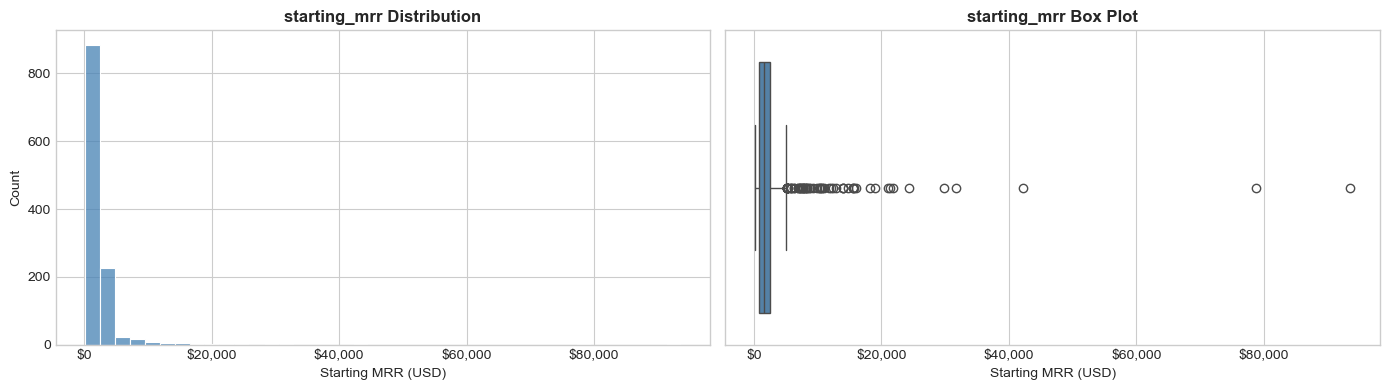

In [24]:
# Value counts and basic stats
print('=== starting_mrr value counts (top 20) ===')
print(df['starting_mrr'].value_counts(dropna=False).head(20))
print(f'\nUnique values: {df["starting_mrr"].nunique()}')
print(f'Missing: {df["starting_mrr"].isnull().sum()} ({df["starting_mrr"].isnull().mean():.1%})')

# Distribution plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df['starting_mrr'].dropna(), bins=40, ax=axes[0], color='steelblue')
axes[0].set_title('starting_mrr Distribution', fontweight='bold')
axes[0].set_xlabel('Starting MRR (USD)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

sns.boxplot(x=df['starting_mrr'].dropna(), ax=axes[1], color='steelblue')
axes[1].set_title('starting_mrr Box Plot', fontweight='bold')
axes[1].set_xlabel('Starting MRR (USD)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()

**Observation:** `starting_mrr` has 155 unique values across 1,273 rows. The most frequent values (433, 866, 1,299, 1,732, 2,598) are clean multiples of a base rate, consistent with standard plan tiers. However, there seems to be large outliers that warrant a closer look.

In [25]:
# How many records exceed a reasonable plan ceiling?
thresholds = [5000, 10000, 20000]

for t in thresholds:
    n = (df['starting_mrr'] > t).sum()
    pct = n / len(df) * 100
    print(f'starting_mrr > ${t:,}: {n} rows ({pct:.1f}%)')

# See the actual outlier records
print('\n=== Records with starting_mrr > $10,000 ===')
print(df[df['starting_mrr'] > 10000][['lifecycle', 'channel', 'service_offering', 'starting_mrr', 'revenue_first_12_months']].sort_values('starting_mrr', ascending=False))

starting_mrr > $5,000: 70 rows (5.5%)
starting_mrr > $10,000: 29 rows (2.3%)
starting_mrr > $20,000: 9 rows (0.7%)

=== Records with starting_mrr > $10,000 ===
      lifecycle            channel     service_offering  starting_mrr  \
423           1            adwords    virtual_assistant    93571.3000   
189           2             avadel                  NaN    78714.2000   
357           1            adwords          outsourcing    42260.8000   
737           1     direct_traffic     customer_support    31782.2000   
613           2      conversations                  NaN    29790.4000   
52            1                NaN                  NaN    24390.0200   
354           1            adwords    virtual_assistant    21779.9000   
509           1            adwords  executive_assistant    21419.9900   
1032          1           facebook  executive_assistant    21054.6300   
188           1             avadel                  NaN    18965.4000   
336           1            adwords  e

**Observation**: A small number of records (2.3%) show starting_mrr above `$10,000`, extending to about `$94,000`. Inspection of these records shows that revenue_first_12_months tracks proportionally in most cases, suggesting these are legitimate large accounts rather than data errors. One exception 
is row 423 (starting_mrr `$93,571`, revenue_first_12_months `$21,968`), which warrants review. Outlier treatment strategy for starting_mrr will be 
decided in the preprocessing phase.

Additionally, missingness (7.4%) will be addressed in the preprocessing phase.

### 3.4 Data Quality Summary

**High-missingness columns (drop before modeling)**: `placement` (99%), `email_industry_type` (90%), `keyword_match_type` (74%), and `keyword_text` (72%) are from platform-specific ad fields. Their signal is already captured by channel and ad_network, and their missingness makes them unusable. These will be dropped.

**Leaky columns (drop before modeling)**: `revenue_first_1_month`, `revenue_first_2_months`, `revenue_first_3_months`, `revenue_first_6_months`, `total_revenue`, `profit`, `latest_mrr`, `last_billing_week`, and `active_weeks` encode post-acquisition behavior. These must be excluded before any feature engineering or model training.

**ID and timestamp columns (drop before modeling)**: `client_id`, `hubspot_client_id`, `attributed_at`, `attributed_date`, `signup_at`, `signup_date`, `customer_date`, and `first_billing_week` serve no predictive role as raw values. Acquisition year or month may be extracted from attributed_at as a cohort control variable if needed.

**High-missingness candidate features (retain with strategy):** `service_offering` (51% missing) is a key segmentation feature; nulls likely reflect unattributed traffic and will be treated as a separate category rather than dropped. `cb_employees_range` (26% missing) and `cb_annual_revenue_ranges` (27% missing) are firmographic signals; nulls will be treated as a separate category. `starting_mrr` (7.4% missing) will be addressed in the preprocessing phase.

**On `starting_mrr`:** The raw MRR value from the first billing week reflects plan and deal configuration at acquisition (the company is a subscription business). With 155 unique values, it captures a mix of clean plan tiers and deal-level variance (multi-assistant configurations, prorations). It will be retained as a numeric feature. Missingness and outliers will be addressed in the preprocessing phase.

**Duplicates:** No full-row duplicates were found.

**Target variable:** `revenue_first_12_months` has no nulls and no negative values, confirming data validity for regression.

---
## 4. Feature Distributions

Univariate analysis of each candidate predictor.

### 4.1 Categorical Features

In [ ]:
CATEGORICALS = [
    'channel',
    'broader_source',
    'service_offering',
    'is_sales_tql',
    'tql_category',
    'initial_plan_type',
    'max_initial_price_point',
    # 'company_industry'  # Uncomment after deciding missingness strategy
]

fig, axes = plt.subplots(len(CATEGORICALS), 1, figsize=(12, 4 * len(CATEGORICALS)))

for ax, col in zip(axes, CATEGORICALS):
    counts = df[col].value_counts(dropna=False)
    pct = counts / len(df) * 100
    labels = [f'{v} ({p:.1f}%)' for v, p in zip(counts.index.astype(str), pct)]
    sns.barplot(x=counts.values, y=counts.index.astype(str), ax=ax, color='steelblue')
    ax.set_title(f'{col}', fontweight='bold')
    ax.set_xlabel('Count')
    ax.set_ylabel('')
    for i, (count, p) in enumerate(zip(counts.values, pct)):
        ax.text(count + 1, i, f'{p:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

### 4.2 Numeric Features

In [ ]:
NUMERICS = [
    'max_initial_default_hours',
    'first_week_mrr',
]

fig, axes = plt.subplots(len(NUMERICS), 2, figsize=(14, 4 * len(NUMERICS)))

for i, col in enumerate(NUMERICS):
    # Histogram
    sns.histplot(df[col].dropna(), bins=40, ax=axes[i][0], color='steelblue')
    axes[i][0].set_title(f'{col} — Distribution', fontweight='bold')
    axes[i][0].set_xlabel(col)

    # Box plot
    sns.boxplot(x=df[col].dropna(), ax=axes[i][1], color='steelblue')
    axes[i][1].set_title(f'{col} — Box Plot', fontweight='bold')
    axes[i][1].set_xlabel(col)

plt.tight_layout()
plt.show()

### 4.3 Feature Distribution Observations

> *(Fill after running cells above)*
> - Are any categorical values too sparse to be useful (< 1% of rows)?
> - Are numeric features skewed? Will they need transformation before modeling?
> - Any unexpected values or anomalies?

---
## 5. Bivariate Analysis — Features vs. Target

This is the most important section for hypothesis generation. We want to understand whether each feature is associated with differences in CLV.

### 5.1 CLV by Service Offering

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Box plot
order = df.groupby('service_offering')[TARGET].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='service_offering', y=TARGET, order=order, ax=axes[0], palette='Blues')
axes[0].set_title('12-Month Revenue by Service Offering', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Revenue (USD)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].tick_params(axis='x', rotation=30)

# Median bar
medians = df.groupby('service_offering')[TARGET].median().sort_values(ascending=False)
sns.barplot(x=medians.index, y=medians.values, ax=axes[1], palette='Blues_d')
axes[1].set_title('Median 12-Month Revenue by Service Offering', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Median Revenue (USD)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

# Summary stats
print(df.groupby('service_offering')[TARGET].agg(['count', 'median', 'mean', 'std']).round(0))

### 5.2 CLV by Acquisition Channel

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

order = df.groupby('channel')[TARGET].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='channel', y=TARGET, order=order, ax=axes[0], palette='Blues')
axes[0].set_title('12-Month Revenue by Channel', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Revenue (USD)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].tick_params(axis='x', rotation=30)

medians = df.groupby('channel')[TARGET].median().sort_values(ascending=False)
sns.barplot(x=medians.index, y=medians.values, ax=axes[1], palette='Blues_d')
axes[1].set_title('Median 12-Month Revenue by Channel', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Median Revenue (USD)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print(df.groupby('channel')[TARGET].agg(['count', 'median', 'mean', 'std']).round(0))

### 5.3 CLV by TQL Status

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# is_sales_tql (boolean)
sns.boxplot(data=df, x='is_sales_tql', y=TARGET, ax=axes[0], palette='Blues')
axes[0].set_title('12-Month Revenue by TQL Status', fontweight='bold')
axes[0].set_xlabel('Is TQL?')
axes[0].set_ylabel('Revenue (USD)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# tql_category (granular)
order = df.groupby('tql_category')[TARGET].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='tql_category', y=TARGET, order=order, ax=axes[1], palette='Blues')
axes[1].set_title('12-Month Revenue by TQL Category', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Revenue (USD)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.show()

print('TQL Status summary:')
print(df.groupby('is_sales_tql')[TARGET].agg(['count', 'median', 'mean']).round(0))
print('\nTQL Category summary:')
print(df.groupby('tql_category')[TARGET].agg(['count', 'median', 'mean']).sort_values('median', ascending=False).round(0))

### 5.4 CLV by Plan Type and Price Point

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

order = df.groupby('initial_plan_type')[TARGET].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='initial_plan_type', y=TARGET, order=order, ax=axes[0], palette='Blues')
axes[0].set_title('12-Month Revenue by Initial Plan Type', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Revenue (USD)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].tick_params(axis='x', rotation=30)

order = df.groupby('max_initial_price_point')[TARGET].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='max_initial_price_point', y=TARGET, order=order, ax=axes[1], palette='Blues')
axes[1].set_title('12-Month Revenue by Initial Price Point', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Revenue (USD)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### 5.5 CLV vs. Numeric Features (Scatter)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, col in zip(axes, NUMERICS):
    ax.scatter(df[col], df[TARGET], alpha=0.3, color='steelblue', s=15)
    ax.set_title(f'{col} vs. 12-Month Revenue', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Revenue (USD)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

    # Add correlation annotation
    corr = df[[col, TARGET]].dropna().corr().iloc[0, 1]
    ax.annotate(f'r = {corr:.3f}', xy=(0.05, 0.93), xycoords='axes fraction', fontsize=11,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

plt.tight_layout()
plt.show()

### 5.6 Bivariate Observations & Hypothesis Seeds

> *(Fill after running cells above. This section is the most important for Checkpoint 1.)*

Based on the bivariate analysis, the following hypotheses are proposed for the modeling phase:

1. **H1 (TQL):** TQL customers will have significantly higher predicted 12-month revenue than non-TQL customers, as TQL status captures company size and budget signals not otherwise visible at acquisition.

2. **H2 (Service offering):** *(Fill based on what you see in the data)*

3. **H3 (Channel):** *(Fill based on what you see in the data)*

4. **H4 (Plan type / price point):** *(Fill based on what you see in the data)*

5. **H5 (Starting hours / MRR):** *(Fill based on scatter plots)*

---
## 6. Segment Analysis

Cross-tabulations of key segment variables. Checks whether modeling cells are populated enough to be useful.

In [ ]:
# Channel × Service Offering — count heatmap
cross = pd.crosstab(df['service_offering'], df['channel'])

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(cross, annot=True, fmt='d', cmap='Blues', ax=ax, linewidths=0.5)
ax.set_title('Customer Count: Service Offering × Channel', fontweight='bold')
ax.set_xlabel('Channel')
ax.set_ylabel('Service Offering')
plt.tight_layout()
plt.show()

In [ ]:
# Channel × Service Offering — median revenue heatmap
cross_rev = df.groupby(['service_offering', 'channel'])[TARGET].median().unstack()

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(cross_rev, annot=True, fmt='.0f', cmap='Blues', ax=ax, linewidths=0.5)
ax.set_title('Median 12-Month Revenue: Service Offering × Channel', fontweight='bold')
ax.set_xlabel('Channel')
ax.set_ylabel('Service Offering')
plt.tight_layout()
plt.show()

In [ ]:
# TQL × Service Offering
cross_tql = pd.crosstab(df['service_offering'], df['is_sales_tql'])
print('Count: Service Offering × TQL Status')
print(cross_tql)

cross_tql_rev = df.groupby(['service_offering', 'is_sales_tql'])[TARGET].median().unstack()
print('\nMedian Revenue: Service Offering × TQL Status')
print(cross_tql_rev.round(0))

### 6.1 Sparse Cell Check

> *(Fill after running cells above)*
> - Are there segment combinations with fewer than ~30 rows? These will be unreliable in modeling.
> - Will any categorical values need to be collapsed or treated as 'other'?

---
## 7. EDA Summary & Modeling Implications

This section is the EDA memo. It synthesizes findings into decisions that carry forward into preprocessing and modeling.

### 7.1 Dataset

| Item | Detail |
|---|---|
| Final row count (after quality filter) | *(fill)* |
| Date range | *(fill)* |
| Features retained | *(fill)* |
| Features excluded | *(fill and reason)* |

### 7.2 Target Variable

> *(Fill: distribution shape, whether log transform will be used, notable outliers)*

### 7.3 Key Findings

> *(Fill: 3–5 concrete findings from the bivariate analysis. E.g., "TQL customers have 2.4× the median revenue of non-TQL customers.")*

### 7.4 Preprocessing Decisions Motivated by EDA

| Decision | Rationale |
|---|---|
| Log-transform target | *(if applicable)* |
| `company_industry` handling | Treat nulls as separate category OR drop — decision: *(fill)* |
| Sparse categories | *(fill: which values will be collapsed)* |
| `first_week_mrr` inclusion | *(fill: include or exclude and why)* |

### 7.5 Hypotheses Carried into Modeling

> *(Copy from Section 5.6 once finalized)*

### 7.6 Data Risks

> *(Fill: any concerns that surfaced in EDA — unexpected distributions, sparse cells, cohort size, etc.)*